----

# Proyecto: ventas de videojuegos. 

Vamos a estudiar este conjunto de datos sobre videojuegos con el propósito de identificar patrones en las ventas del año presente que nos resulten útiles para la toma de decisiones publicitarias,  o de otro tipo, el año que viene. 

Para esto seguiremos el siguiente proceso metodológico: 
- Correcta lectura de los archivos csv
- Preprocesamiento de los datos.
- Agrupamiento de datos, formación de nuevas tablas e ingeniería de características.
- Visualización de datos y análisis estadísticos. 





In [1]:
#importar librerias. 
import pandas as pd
import numpy as np 
import math as mt
from matplotlib import pyplot as plt
from scipy import stats as st


##  Cargar datos.

In [ ]:
df_games = pd.read_csv("/datasets/games.csv")


In [ ]:
df_games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
print(df_games.head(20))


                                            Name Platform  Year_of_Release  \
0                                     Wii Sports      Wii           2006.0   
1                              Super Mario Bros.      NES           1985.0   
2                                 Mario Kart Wii      Wii           2008.0   
3                              Wii Sports Resort      Wii           2009.0   
4                       Pokemon Red/Pokemon Blue       GB           1996.0   
5                                         Tetris       GB           1989.0   
6                          New Super Mario Bros.       DS           2006.0   
7                                       Wii Play      Wii           2006.0   
8                      New Super Mario Bros. Wii      Wii           2009.0   
9                                      Duck Hunt      NES           1984.0   
10                                    Nintendogs       DS           2005.0   
11                                 Mario Kart DS       DS       

"Se comprueba que se leyeron correctamente los datos. Hay pocas columnas con algun dato ausente, pero es en las columnas Critic_Score, User_Score y Rating donde mas valores ausentes se observan. Habra que investigar porque se generaron esos valores ausentes, para de esta manera poder decidir"

## Preprocesar el DataFrame original.

### Nombres de columnas.

In [ ]:
#transformar el nombre de las columnas, pasando todas las letras a minusculas.abs 
df_games.columns = df_games.columns.str.lower()
print(df_games.columns)


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


### Duplicados.

In [ ]:
#revisar si hay filas completamente duplicadas en el DataFrame. 
print("Numero de filas duplicadas:", df_games.duplicated().sum())


Numero de filas duplicadas: 0


In [7]:
#revisar si hay nombres de videojuegos repetidos.

print('Numero de filas con mismo valor en la columna name :', df_games['name'].duplicated().sum())



duplicados_nombres = df_games[df_games.duplicated(subset=['name'], keep=False)]
duplicados_nombres = duplicados_nombres.sort_values('name')
duplicados_nombres.reset_index(drop=True)

print(duplicados_nombres.head(20))



Numero de filas con mismo valor en la columna name : 5155
                                                    name platform  \
3862                                Frozen: Olaf's Quest       DS   
3358                                Frozen: Olaf's Quest      3DS   
14658                             007: Quantum of Solace       PC   
9507                              007: Quantum of Solace       DS   
3120                              007: Quantum of Solace      Wii   
1285                              007: Quantum of Solace     X360   
1785                              007: Quantum of Solace      PS3   
4475                              007: Quantum of Solace      PS2   
2243                        007: The World is not Enough       PS   
1204                        007: The World is not Enough      N64   
15656                                  11eyes: CrossOver      PSP   
15091                                  11eyes: CrossOver     X360   
10076                   18 Wheeler: American 

"Viendo si había duplicados encontramos que no había filas completamente duplicadas, pero al revisar si había nombres de videojuegos repetidos encontramos que sí había. Filtrando estos duplicados vimos que hay nombres repetidos, pero que lo que cambia es la plataforma en donde fueron liberados. Por ello conservamos todas esas filas con nombres repetidos, porque un mismo juego liberado en distintas plataformas tiene ventas distintas y tiene que tratarse como un juego distinto."

### Valores ausentes

In [ ]:
df_games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#### Columna 'name'. 

In [ ]:
#revisando los valores ausentes en la columna 'name'.
filas_ausentes_name = df_games[df_games['name'].isna()]
print("Filas con NaN en columna 'name': \n", filas_ausentes_name)
print()
print()
print()
print("Filas con valor 'GEN' en columna 'platform': \n", df_games[df_games['platform'] == 'GEN'])


Filas con NaN en columna 'name': 
       name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  



Filas con valor 'GEN' en columna 'platform': 
                                                     name platform  \
145                                 Sonic the Hedgehog 2      GEN   
257                                   Sonic the Hedgehog      GEN   
564                                        Mortal Kombat      GEN   
588                                      Streets of Rage      GEN   
659                                                  NaN      GEN   
832                                              NBA Jam      GEN   
960                                     Soni

In [ ]:
# sustitucion de NaN en columna 'name' por el string 'sin_nombre'
df_games['name'] = df_games['name'].fillna('sin_nombre')

print(df_games[df_games['name'] == 'sin_nombre'])


             name platform  year_of_release genre  na_sales  eu_sales  \
659    sin_nombre      GEN           1993.0   NaN      1.78      0.53   
14244  sin_nombre      GEN           1993.0   NaN      0.00      0.00   

       jp_sales  other_sales  critic_score user_score rating  
659        0.00         0.08           NaN        NaN    NaN  
14244      0.03         0.00           NaN        NaN    NaN  


"Revisando las filas con valores ausentes en la columna 'name' encontramos dos filas que comparten haber sido liberados en 1993 y además ser liberados en la plataforma GEN. A partir de esta información busque todos los videojuegos liberados en esta plataforma para ver si solo eran estos dos o si había más, y en efecto había más. La plataforma GEN parece ser una plataforma de videojuegos de la década de los 90 y todos estos juegos comparten no tener calificación del usuario, ni calificación de la crítica y tampoco clasificación ESRB. Esto es posible porque en los 90 aún no se emitieran de manera sistemática estas calificaciones ni se emitiera una clasificación ESRB de todos los juegos, esta última comenzó a emitirse a partir del 16 de septiembre de 1994. Porque los juegos liberados en esta plataforma son muy pocos y eliminar dos elementos de este conjunto representaría una proporción importante de la venta de videojuegos de esta plataforma, decidimos dejar estas filas y llenar los valores ausentes con la entrada 'sin
_nombre'"

#### Columna 'year_of_release'

In [11]:
#revisando los valores ausentes en la columna 'year_of_release'.
filas_ausentes_year = df_games[df_games['year_of_release'].isna()]
print("Número de filas con NaN en year_of_release:", filas_ausentes_year.shape[0])
print()
print()
print()
print("Información de filas con NaN en year_of_release:")
print(filas_ausentes_year.info())
print()
print()
print()
print(filas_ausentes_year.sample(20))


Número de filas con NaN en year_of_release: 269



Información de filas con NaN en year_of_release:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 269 entries, 183 to 16522
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             269 non-null    object 
 1   platform         269 non-null    object 
 2   year_of_release  0 non-null      float64
 3   genre            269 non-null    object 
 4   na_sales         269 non-null    float64
 5   eu_sales         269 non-null    float64
 6   jp_sales         269 non-null    float64
 7   other_sales      269 non-null    float64
 8   critic_score     154 non-null    float64
 9   user_score       175 non-null    object 
 10  rating           181 non-null    object 
dtypes: float64(6), object(5)
memory usage: 25.2+ KB
None



                                                    name platform  \
6255   The Legend of Zelda: The Minish Cap(weekly JP ...      G

In [ ]:
#investigando mas los videojuegos con valores ausentes en year of release. 

# Analizar patrones en los valores ausentes de year_of_release
filas_ausentes_year = df_games[df_games['year_of_release'].isna()].copy()

print("=== ANÁLISIS DE VALORES AUSENTES EN YEAR_OF_RELEASE ===\n")

# 1. Distribución por plataforma
print("1. Distribución por plataforma:")
print(filas_ausentes_year['platform'].value_counts().head(10))
print()

# 2. Ventas totales de estos juegos
filas_ausentes_year['total_sales'] = (filas_ausentes_year['na_sales'] + 
                                     filas_ausentes_year['eu_sales'] + 
                                     filas_ausentes_year['jp_sales'] + 
                                     filas_ausentes_year['other_sales'])

print("2. Estadísticas de ventas totales (juegos sin año):")
print(filas_ausentes_year['total_sales'].describe())
print()

# 3. ¿Tienen calificaciones?
print("3. Disponibilidad de calificaciones:")
print(f"Con Critic_Score: {filas_ausentes_year['critic_score'].notna().sum()}")
print(f"Con User_Score: {filas_ausentes_year['user_score'].notna().sum()}")
print(f"Con Rating: {filas_ausentes_year['rating'].notna().sum()}")


=== ANÁLISIS DE VALORES AUSENTES EN YEAR_OF_RELEASE ===

1. Distribución por plataforma:
PS2     34
Wii     34
X360    30
DS      30
PS3     25
XB      21
PC      17
2600    17
PSP     16
GC      14
Name: platform, dtype: int64

2. Estadísticas de ventas totales (juegos sin año):
count    269.000000
mean       0.367732
std        0.613082
min        0.010000
25%        0.050000
50%        0.160000
75%        0.380000
max        5.240000
Name: total_sales, dtype: float64

3. Disponibilidad de calificaciones:
Con Critic_Score: 154
Con User_Score: 175
Con Rating: 181


In [ ]:
# Reemplazar valores ausentes en year_of_release por 0
df_games['year_of_release'] = df_games['year_of_release'].fillna(0)

# Verificar el cambio
print("El numero de videojuegos en df_games que tienen valor 0 en year_of_release:", df_games[df_games['year_of_release'] == 0].shape[0])


El numero de videojuegos en df_games que tienen valor 0 en year_of_release: 269


"Al revisar los valores ausentes en la columna, intente observar si existía algún patrón claro que me diera alguna idea del porqué se habían registrado como datos ausentes. Lo que encontramos es que la manera como se distribuyen estos videojuegos es muy diversa por lo que no se puede ver claramente porque no se registraron estos valores. Lo que si se puede ver es que tan solo representan el 1.6% de mis filas totales, por lo que aunque uno podría pensar que por ser tan poco porcentaje uno podría eliminarlos y ya, resulta que en casi el resto de columnas si tienen datos completos y además en la distribución de ingresos es muy amplia, teniendo un mínimo de ingresos totales de 0.01 millones como mínimo y 5.24 millones. Por todo esto Los 269 valores ausentes en year_of_release fueron reemplazados por 0 para mantener el tipo numérico de la columna. El valor 0 representa años desconocidos y puede ser fácilmente filtrado en análisis temporales."

#### Columna 'genre'

In [ ]:
#revisando los valores ausentes en la columna 'genre'.
filas_ausentes_genre = df_games[df_games['genre'].isna()]
print("Número de filas con NaN en genre:", filas_ausentes_genre.shape[0])
print()
print()
print()
print("Información de filas con NaN en genre:")
print(filas_ausentes_genre.info())
print()
print()
print()
print(filas_ausentes_genre.head())


Número de filas con NaN en genre: 2



Información de filas con NaN en genre:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2 entries, 659 to 14244
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2 non-null      object 
 1   platform         2 non-null      object 
 2   year_of_release  2 non-null      float64
 3   genre            0 non-null      object 
 4   na_sales         2 non-null      float64
 5   eu_sales         2 non-null      float64
 6   jp_sales         2 non-null      float64
 7   other_sales      2 non-null      float64
 8   critic_score     0 non-null      float64
 9   user_score       0 non-null      object 
 10  rating           0 non-null      object 
dtypes: float64(6), object(5)
memory usage: 192.0+ bytes
None



             name platform  year_of_release genre  na_sales  eu_sales  \
659    sin_nombre      GEN           1993.0   NaN      1.78      0.53   
14244 

In [ ]:
# Reemplazar valores ausentes en genre por sin_genero
df_games['genre'] = df_games['genre'].fillna('sin_genero')

# Verificar el cambio
print("El numero de videojuegos en df_games que tienen valor sin_genero en genre:", df_games[df_games['genre'] == 'sin_genero'].shape[0])
print()
print()
print()
df_games.info()


El numero de videojuegos en df_games que tienen valor sin_genero en genre: 2



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#### Columna 'critic_score'.

In [ ]:
#revisando los valores ausentes en la columna 'critic_score'.
filas_ausentes_critic_score = df_games[df_games['critic_score'].isna()]
print("Número de filas con NaN en critic_score:", filas_ausentes_critic_score.shape[0])
print()
print()
print()
print("Información de filas con NaN en critic_score:")
print(filas_ausentes_critic_score.info())
print()
print()
print()
print(filas_ausentes_critic_score.sample(20))


Número de filas con NaN en critic_score: 8578



Información de filas con NaN en critic_score:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 8578 entries, 1 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             8578 non-null   object 
 1   platform         8578 non-null   object 
 2   year_of_release  8578 non-null   float64
 3   genre            8578 non-null   object 
 4   na_sales         8578 non-null   float64
 5   eu_sales         8578 non-null   float64
 6   jp_sales         8578 non-null   float64
 7   other_sales      8578 non-null   float64
 8   critic_score     0 non-null      float64
 9   user_score       1915 non-null   object 
 10  rating           1895 non-null   object 
dtypes: float64(6), object(5)
memory usage: 804.2+ KB
None



                                                    name platform  \
9415                                     I Spy: Universe       DS   

In [ ]:
#investigando mas los videojuegos con valores ausentes en critic_score. 

# Analizar patrones en los valores ausentes de critic_score
filas_ausentes_critic_score = df_games[df_games['critic_score'].isna()].copy()

print("=== ANÁLISIS DE VALORES AUSENTES EN CRITIC_SCORE ===\n")

# 1. Distribución por plataforma
print("1. Distribución por plataforma:")
print(filas_ausentes_critic_score['platform'].value_counts().head(15))
print()

# 2. Distribución por year_of_release
print("2. Distribución por year_of_release:")
print(filas_ausentes_critic_score['year_of_release'].value_counts())
print()

# 3. Distribución por genre
print("3. Distribución por genre:")
print(filas_ausentes_critic_score['genre'].value_counts())
print()

# 4. Ventas totales de estos juegos
filas_ausentes_critic_score['total_sales'] = (filas_ausentes_critic_score['na_sales'] + 
                                     filas_ausentes_critic_score['eu_sales'] + 
                                     filas_ausentes_critic_score['jp_sales'] + 
                                     filas_ausentes_critic_score['other_sales'])

print("4. Estadísticas de ventas totales (juegos sin critic_score):")
print(filas_ausentes_critic_score['total_sales'].describe())
print()

# 5. Estadisticas descriptivas de esta columna
print("5. Estadísticas de la distribucion de critic_score en filas con valores no ausentes:")
print(df_games[df_games['critic_score'].notna()]['critic_score'].describe())
print()

# 6. ¿Tienen calificaciones?
print("6. Disponibilidad de calificaciones:")
print(f"Con User_Score: {filas_ausentes_critic_score['user_score'].notna().sum()}")
print(f"Con Rating: {filas_ausentes_critic_score['rating'].notna().sum()}")


=== ANÁLISIS DE VALORES AUSENTES EN CRITIC_SCORE ===

1. Distribución por plataforma:
DS      1434
PS       997
PS2      863
PSP      747
Wii      735
PS3      511
GBA      384
3DS      352
X360     346
N64      319
PSV      310
PC       259
SNES     239
SAT      173
PS4      140
Name: platform, dtype: int64

2. Distribución por year_of_release:
2009.0    775
2010.0    755
2008.0    712
2011.0    636
2007.0    505
2006.0    386
2015.0    381
1998.0    351
2012.0    332
2014.0    320
1999.0    299
2005.0    284
1997.0    272
2013.0    271
2016.0    270
1996.0    255
1995.0    219
2000.0    207
2002.0    202
2004.0    201
2003.0    190
2001.0    156
1994.0    120
0.0       115
1993.0     62
1981.0     46
1992.0     42
1991.0     41
1982.0     36
1986.0     21
1989.0     17
1983.0     17
1987.0     16
1990.0     16
1988.0     14
1984.0     14
1985.0     13
1980.0      9
Name: year_of_release, dtype: int64

3. Distribución por genre:
Action          1479
Misc            1227
Sports        

In [ ]:
# Reemplazar valores ausentes en critic_score por -1
df_games['critic_score'] = df_games['critic_score'].fillna(-1)

# Verificar el cambio
print("El numero de videojuegos en df_games que tienen valor -1 en critic_score:", df_games[df_games['critic_score'] == -1].shape[0])
print()
print()
print()
df_games.info()


El numero de videojuegos en df_games que tienen valor -1 en critic_score: 8578



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


"Al revisar el perfil de los videojuegos que tienen valor ausente en la columna critic_score, nos podemos dar cuenta que es un poco más del 50% de los datos totales, por lo que eliminar estos datos ausentes o rellenarlos con valores estadísticos como la media y la mediana tampoco es opción, ya que esto podría crear falsas relaciones estadísticas al asumir el valor de la calificación de tantos datos. Además, no se pudo identificar algún patrón detrás del porqué faltan estos valores. Los valores ausentes están distribuidos sin ningún patrón claro en una colección amplia de plataformas, géneros, e incluso en el year_of_release, que aunque hay más valores faltantes en años recientes, también hay en anteriores. Por todo esto decidí sustituir el valor ausente NaN por el valor -1, ya que así mantenemos la integridad de los datos y no introducimos valores artificiales, fácilmente podemos filtrar o analizar por separado los juegos con y sin calificaciones y además conservamos el tipo de dato de la columna"

#### Columna 'user_score'.

In [ ]:
#revisando los valores ausentes en la columna 'user_score'.
filas_ausentes_user_score = df_games[df_games['user_score'].isna()]
print("Número de filas con NaN en user_score:", filas_ausentes_user_score.shape[0])
print()
print()
print()
print("Información de filas con NaN en user_score:")
print(filas_ausentes_user_score.info())
print()
print()
print()
print(filas_ausentes_user_score.sample(20))


Número de filas con NaN en user_score: 6701



Información de filas con NaN en user_score:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 6701 entries, 1 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             6701 non-null   object 
 1   platform         6701 non-null   object 
 2   year_of_release  6701 non-null   float64
 3   genre            6701 non-null   object 
 4   na_sales         6701 non-null   float64
 5   eu_sales         6701 non-null   float64
 6   jp_sales         6701 non-null   float64
 7   other_sales      6701 non-null   float64
 8   critic_score     6701 non-null   float64
 9   user_score       0 non-null      object 
 10  rating           71 non-null     object 
dtypes: float64(6), object(5)
memory usage: 628.2+ KB
None



                                                name platform  \
13471      Choro Q 64 2: Hacha Mecha Grand Prix Race      N64   
15937      

In [ ]:
#investigando mas los videojuegos con valores ausentes en user_score. 

# Analizar patrones en los valores ausentes de user_score
filas_ausentes_user_score = df_games[df_games['user_score'].isna()].copy()

print("=== ANÁLISIS DE VALORES AUSENTES EN USER_SCORE ===\n")

# 1. Distribución por plataforma
print("1. Distribución por plataforma:")
print(filas_ausentes_user_score['platform'].value_counts().head(15))
print()

# 2. Distribución por year_of_release
print("2. Distribución por year_of_release:")
print(filas_ausentes_user_score['year_of_release'].value_counts())
print()

# 3. Distribución por genre
print("3. Distribución por genre:")
print(filas_ausentes_user_score['genre'].value_counts())
print()

# 4. Ventas totales de estos juegos
filas_ausentes_user_score['total_sales'] = (filas_ausentes_user_score['na_sales'] + 
                                     filas_ausentes_user_score['eu_sales'] + 
                                     filas_ausentes_user_score['jp_sales'] + 
                                     filas_ausentes_user_score['other_sales'])

print("4. Estadísticas de ventas totales (juegos sin user_score):")
print(filas_ausentes_user_score['total_sales'].describe())
print()

# 5. Estadisticas descriptivas de esta columna
print("5. Estadísticas de la distribucion de user_score en filas con valores no ausentes:")
print(df_games[df_games['user_score'].notna()]['user_score'].describe())
print()

# 6.Value counts de la columna user_score.
print("6. Value counts de la columna user_score")
print(df_games[df_games['user_score'].notna()]['user_score'].value_counts())
print()


# 7. ¿Tienen calificaciones?
print("7. Disponibilidad de calificaciones:")
print(f"Con Rating: {filas_ausentes_user_score['rating'].notna().sum()}")


=== ANÁLISIS DE VALORES AUSENTES EN USER_SCORE ===

1. Distribución por plataforma:
PS      990
DS      879
PS2     680
PSP     665
PS3     367
Wii     320
N64     319
GBA     305
3DS     290
PSV     280
SNES    239
X360    212
SAT     173
PC      155
2600    133
Name: platform, dtype: int64

2. Distribución por year_of_release:
2010.0    457
2008.0    440
2011.0    418
2009.0    407
2007.0    376
1998.0    348
2006.0    330
1999.0    299
2012.0    290
2015.0    271
1997.0    270
1996.0    255
2005.0    235
2014.0    231
2013.0    225
1995.0    219
2016.0    206
2000.0    200
2002.0    173
2004.0    166
2003.0    164
2001.0    143
1994.0    120
0.0        94
1993.0     62
1981.0     46
1992.0     42
1991.0     41
1982.0     36
1986.0     21
1989.0     17
1983.0     17
1990.0     16
1987.0     16
1984.0     14
1988.0     14
1985.0     13
1980.0      9
Name: year_of_release, dtype: int64

3. Distribución por genre:
Action          1163
Misc             862
Adventure        844
Sports    

In [ ]:
# Reemplazar valores ausentes en user_score por -1
df_games['user_score'] = df_games['user_score'].replace('tbd', -1)
df_games['user_score'] = df_games['user_score'].fillna(-1)

# Verificar el cambio
print("El numero de videojuegos en df_games que tienen valor -1 en user_score:", df_games[df_games['user_score'] == -1].shape[0])
print()
print()
print()
df_games.info()


El numero de videojuegos en df_games que tienen valor -1 en user_score: 9125



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       16715 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


"En la columna user_score sucede que además de los valores ausentes NaN, tenemos también valores 'tbd' que significan 'To be determined', que a fines de un análisis numérico, no importa si son videojuegos con calificación pendiente o simplemente que nunca se intentó calificar el videojuego, lo que importa es que no se va a poder hacer una relación entre la calificación del usuario de estos videojuegos y sus ventas totales. Por todo esto es que decidí tomar tanto los valores ausentes NaN y los tbt y los sustituí por el valor imposible -1, esto también con la finalidad de no perder el valor numérico de la columna, pero al mismo tiempo poder filtrar fácilmente estas filas y analizarlas aparte"

#### Columna 'rating'.

In [ ]:
#revisando los valores ausentes en la columna 'rating'.
filas_ausentes_rating = df_games[df_games['rating'].isna()]
print("Número de filas con NaN en rating:", filas_ausentes_rating.shape[0])
print()
print()
print()
print("Información de filas con NaN en rating:")
print(filas_ausentes_rating.info())
print()
print()
print()
print(filas_ausentes_rating.sample(20))


Número de filas con NaN en rating: 6766



Información de filas con NaN en rating:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 6766 entries, 1 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             6766 non-null   object 
 1   platform         6766 non-null   object 
 2   year_of_release  6766 non-null   float64
 3   genre            6766 non-null   object 
 4   na_sales         6766 non-null   float64
 5   eu_sales         6766 non-null   float64
 6   jp_sales         6766 non-null   float64
 7   other_sales      6766 non-null   float64
 8   critic_score     6766 non-null   float64
 9   user_score       6766 non-null   object 
 10  rating           0 non-null      object 
dtypes: float64(6), object(5)
memory usage: 634.3+ KB
None



                                                    name platform  \
3790                                     Front Mission 2       PS   
11286  Fami

In [23]:
#investigando mas los videojuegos con valores ausentes en rating. 

# Analizar patrones en los valores ausentes de rating
filas_ausentes_rating = df_games[df_games['rating'].isna()].copy()

print("=== ANÁLISIS DE VALORES AUSENTES EN RATING ===\n")

# 1. Distribución por plataforma
print("1. Distribución por plataforma:")
print(filas_ausentes_rating['platform'].value_counts().head(15))
print()

# 2. Distribución por year_of_release
print("2. Distribución por year_of_release:")
print(filas_ausentes_rating['year_of_release'].value_counts())
print()

# 3. Distribución por genre
print("3. Distribución por genre:")
print(filas_ausentes_rating['genre'].value_counts())
print()

# 4. Ventas totales de estos juegos
filas_ausentes_rating['total_sales'] = (filas_ausentes_rating['na_sales'] + 
                                     filas_ausentes_rating['eu_sales'] + 
                                     filas_ausentes_rating['jp_sales'] + 
                                     filas_ausentes_rating['other_sales'])

print("4. Estadísticas de ventas totales (juegos sin rating):")
print(filas_ausentes_rating['total_sales'].describe())
print()

# 5. Estadisticas descriptivas de esta columna
print("5. Estadísticas de la distribucion de rating en filas con valores no ausentes:")
print(df_games[df_games['rating'].notna()]['rating'].describe())
print()

# 6.Value counts de la columna user_score.
print("6. Value counts de la columna rating")
print(df_games[df_games['rating'].notna()]['rating'].value_counts())
print()


=== ANÁLISIS DE VALORES AUSENTES EN RATING ===

1. Distribución por plataforma:
PS      989
DS      878
PS2     680
PSP     665
PS3     379
N64     319
Wii     318
GBA     300
3DS     292
PSV     279
SNES    239
X360    210
PC      200
SAT     173
PS4     137
Name: platform, dtype: int64

2. Distribución por year_of_release:
2010.0    456
2008.0    446
2011.0    433
2009.0    415
2007.0    376
1998.0    347
2006.0    328
2012.0    298
1999.0    296
2015.0    291
1997.0    270
1996.0    256
2014.0    236
2005.0    233
2013.0    228
2016.0    222
1995.0    219
2000.0    202
2002.0    174
2004.0    164
2003.0    162
2001.0    143
1994.0    120
0.0        88
1993.0     62
1981.0     46
1992.0     41
1991.0     41
1982.0     36
1986.0     21
1989.0     17
1983.0     17
1990.0     16
1987.0     16
1984.0     14
1988.0     14
1985.0     13
1980.0      9
Name: year_of_release, dtype: int64

3. Distribución por genre:
Action          1181
Misc             868
Adventure        857
Sports        

In [ ]:
# Reemplazar valores ausentes en rating por 'sin_rarting'
df_games['rating'] = df_games['rating'].fillna('sin_rating')

# Verificar el cambio
print("El numero de videojuegos en df_games que tienen valor sin_rating en rating:", df_games[df_games['rating'] == 'sin_rating'].shape[0])
print()
print()
print()
df_games.info()


El numero de videojuegos en df_games que tienen valor sin_rating en rating: 6766



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  float64
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       16715 non-null  object 
 10  rating           16715 non-null  object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


"También aqui, por la amplia distribucion de los datos en el resto de columnas, se decidió simplemente sustituir el valor NaN por el string 'sin_rating'"

### Tipos de datos de cada columna.

In [ ]:
# Convertir year_of_release de float a int
df_games['year_of_release'] = df_games['year_of_release'].astype(int)
# Convertir user_score de object a float
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')
# Verificar los cambios
print("Información del DataFrame después de las conversiones:")
df_games.info()


Información del DataFrame después de las conversiones:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


## Ingeniería de características.

In [ ]:
# Verificar valores ausentes en columnas de ventas
print("Valores ausentes en columnas de ventas:")
sales_columns = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
print(df_games[sales_columns].isnull().sum())


Valores ausentes en columnas de ventas:
na_sales       0
eu_sales       0
jp_sales       0
other_sales    0
dtype: int64


In [27]:
# Agregar la columna de total_sales al dataframe.
df_games['total_sales'] = (df_games['na_sales'] + 
                                     df_games['eu_sales'] + 
                                     df_games['jp_sales'] + 
                                     df_games['other_sales'])


In [ ]:
df_games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  object 
 11  total_sales      16715 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.5+ MB


"Se calcularon las ventas totales para cada videojuego como la suma de las ventas individuales de cada región. Se calculó para todos los videojuegos y se agregó como una columna del dataframe con todos estos valores en la fila respectiva de cada videojuego."

## Visualización y análisis.

- Juegos lanzados por año
- diferencia o variacion de las ventas en funcion de plataforma
- Plataformas con mayores ventas totales, su distribucion basada en los datos de cada año, plataformas que solian ser populares pero que ahora ya no tienen ventas, cuanto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer.
- Periodo a tomar para la prediccion del año que viene. 
- Plataformas lideres en ventas.
- Plataformas potencialmente rentables.
- Diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma.
- Correlacion entre reseñas de usuarios y profesionales y las ventas de una plataforma popular.
- Distribución general de los juegos por género, géneros más rentables.
  

### Juegos lanzados por año.

In [ ]:
# Juegos lanzados por año. 
print(df_games['year_of_release'].value_counts().sort_index())


0        269
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64


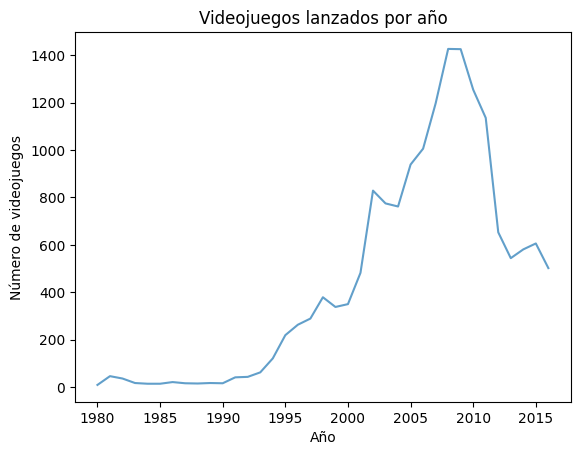

In [ ]:

df_games[(~(df_games['year_of_release'] == 0))]['year_of_release'].value_counts().sort_index().plot(kind='line', alpha=0.7)
plt.title('Videojuegos lanzados por año')
plt.xlabel('Año')
plt.ylabel('Número de videojuegos')
plt.show()


"Podemos observar que hubo un incremento gradual en la liberación de videojuegos hasta el inicio de los 2000 que llego a su pico poco antes del 2010 y que a partir de entonces ha estado bajando."

### Variación de ventas en función de plataforma. 

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

Top 10 plataformas por ventas totales:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64



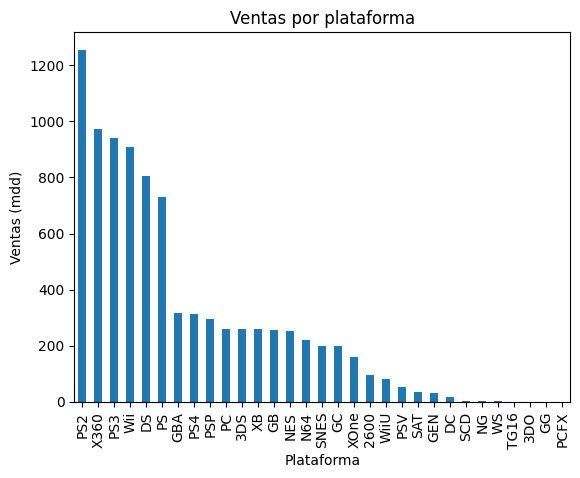

In [ ]:
ventas_por_plataforma = df_games.groupby(by='platform')['total_sales'].sum().sort_values(ascending=False)
print(ventas_por_plataforma)
print()
# Ventas totales por plataforma
print("Top 10 plataformas por ventas totales:")
print(ventas_por_plataforma.head(10))
print()
ventas_por_plataforma.plot(kind='bar')
plt.title('Ventas por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas (mdd)')
plt.show()


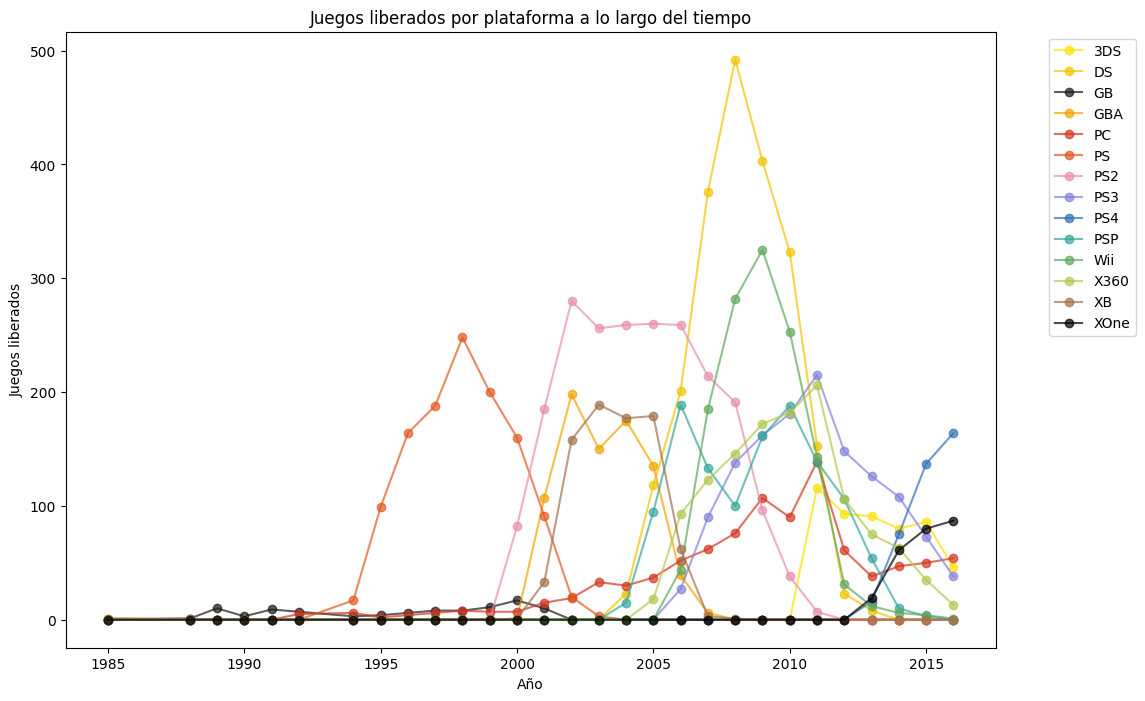

In [ ]:
# Seleccionar top 5-8 plataformas
top_platforms = ventas_por_plataforma.head(12).index.tolist()
top_platforms.append('XOne')
top_platforms.append('GB')

# Ventas por plataforma y año
platform_year_release = df_games[(df_games['platform'].isin(top_platforms)) & ~(df_games['year_of_release'] == 0)].groupby(['year_of_release', 'platform']).size().unstack(fill_value=0)

# Crear gráfico
# Define tus 14 colores

personalizados = ['#FCE205', '#f3c300', '#1a1a1a','#f4a300', '#d4351e',
    '#e25822', '#e68fac', '#8481dd', '#3070b3',
    '#35a79c', '#5fa85b', '#b2c84d', '#a47149', '#000000']
 

platform_year_release.plot(kind='line', figsize=(12, 8), style='o-', alpha=0.7, color=personalizados)
plt.title('Juegos liberados por plataforma a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Juegos liberados')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


"Es importante notar que los datos que tenemos sobre las ventas de los videojuegos son realmente las ventas acumuladas desde el año de su lanzamiento hasta 2016, así que no tenemos acceso a las ventas incrementales año por año en cada videojuego. Así que con esto en mente primero realizamos un gráfico en donde se observa la venta acumulada en función de las plataformas y después, para poder identificar el ciclo de vida de las plataformas y las tendencias del año 2016, hice un gráfico en donde se pudiera ver año con año la cantidad de juegos liberados en cada plataforma del top 10 en ventas totales. A partir de aquí podemos ver que los ciclos de vida de cada plataforma desde que inician hasta que no tienen actividad son de aproximadamente 10 o 13 años, con algunos durando más (el caso de la PC) y algunos durando menos (el caso del GBA y Wii). Por lo tanto, consideramos que las plataformas rentables para 2017 son aquellas de no más de 15 años de antigüedad, que tengan una tendencia positiva en el aumento de actividad de desarrollo de juegos y/o que estén bien colocadas en ventas, ya sea ellas mismas o alguna de sus generaciones anteriores de la misma marca. Bajo estos supuestos consideramos que algunas de las plataformas más rentables para 2017 serían: PS4, XOne, PC, PS3, X360, 3DS.

Otra cosa importante a notar es que es importante combinar los dos gráficos presentados para darnos una idea del retorno de inversión, ya que viendo el volumen de juegos liberados en una plataforma multiplicado por el volumen de ventas por plataforma es que nos podemos dar una idea del impacto real que cada plataforma tuvo durante cada año. "

### Mediana y cuartiles de la distribucion de ventas totales por plataforma.

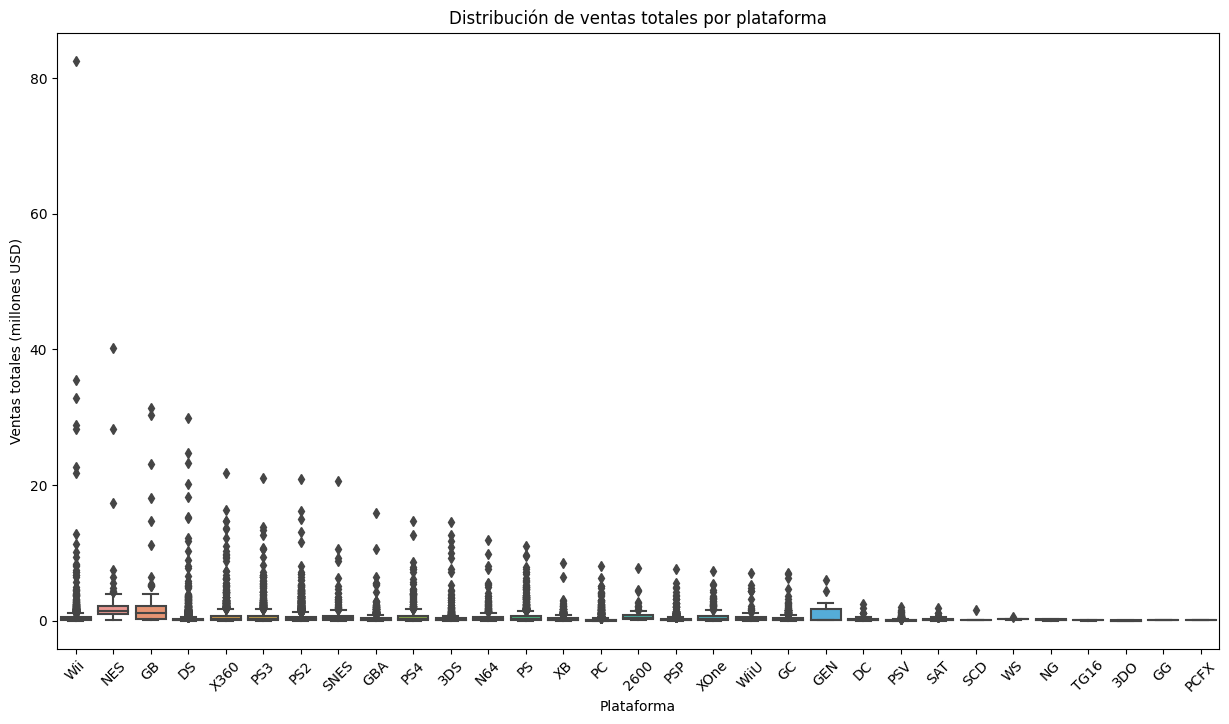

In [ ]:
import seaborn as sns

# Opción 1: Boxplot vertical
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_games, x='platform', y='total_sales')
plt.title('Distribución de ventas totales por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones USD)')
plt.xticks(rotation=45)
plt.show()


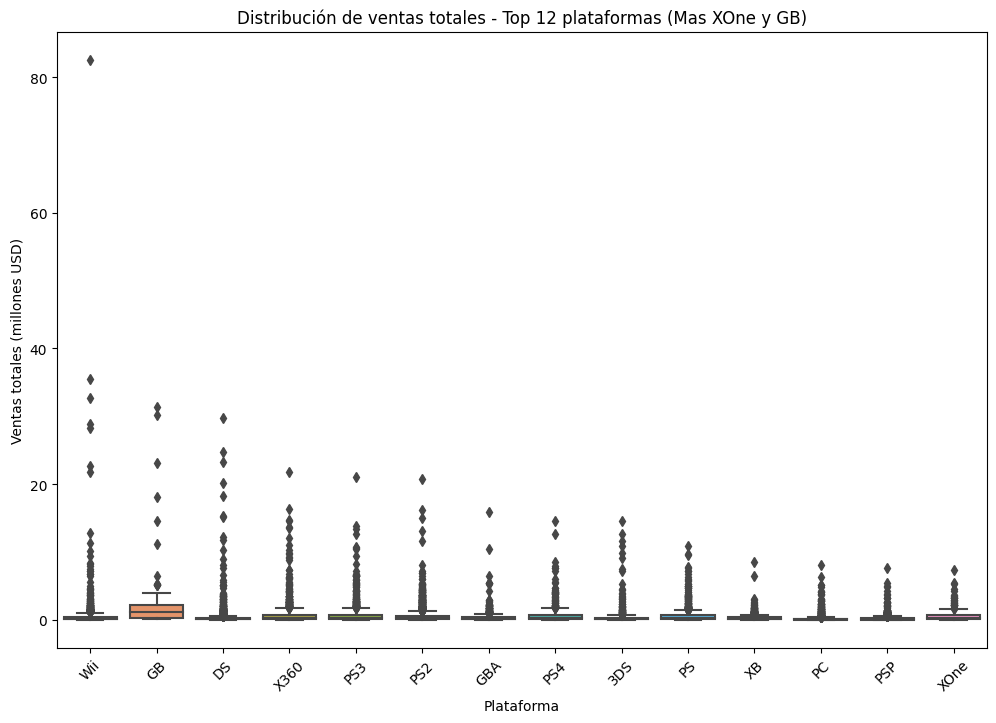

In [ ]:
df_top_platforms = df_games[df_games['platform'].isin(top_platforms)]

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_top_platforms, x='platform', y='total_sales')
plt.title('Distribución de ventas totales - Top 12 plataformas (Mas XOne y GB)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones USD)')
plt.xticks(rotation=45)
plt.show()


"Notemos que, a partir de estos gráficos de caja, podemos concluir que la mediana de las ventas totales por videojuego en todas las plataformas, incluidas el top en ventas, esta cercana a 0. Lo que esto nos indica es que la mayor proporción de las ventas totales asociadas a cada plataforma no están dadas por el volumen de videojuegos liberados en dicha plataforma, sino que, más bien, están dadas por valores atípicos. La acumulación de videojuegos atípicos que se despegaron de la mediana de ventas de la plataforma y acumularon muchas ventas es lo que constituye la mayor o menor rentabilidad de la plataforma. Es interesante notar que uno de los únicos casos que no cumple esta regla es la plataforma GB, ya que viendo la cronología de videojuegos liberados, vemos que libero muy pocos juegos en su ciclo de vida, sin embargo, por la gráfica de caja, podemos observar que su mediana se despega de cero un poco más. Esto se puede interpretar como que si uno sacaba un videojuego en la plataforma GB, parece probable que esperáramos ventas mayores que en otras plataformas. Esto es posible debido a que en la época de vida de la plataforma GB, el mercado de los videojuegos no estuviera tan competido y por ello las pocas plataformas que había tenían mayores ventas en cualquier videojuego que liberaran."

### Correlación entre calificaciones y ventas.

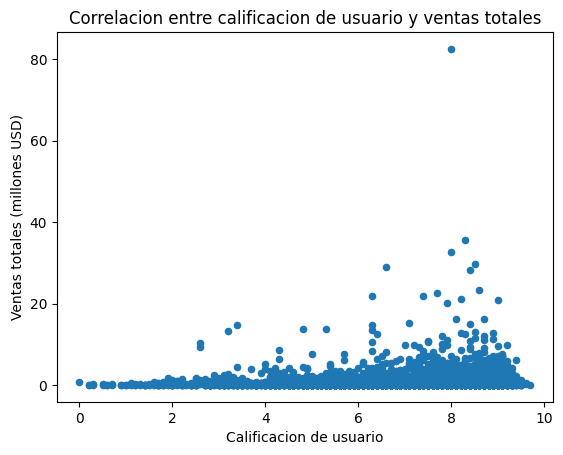

Coeficiente de correlacion de Pearson:
0.08817911987579136


In [ ]:
df_games_con_user_score = df_games[~(df_games['user_score'] == -1)]
df_games_con_user_score.plot(x='user_score', y='total_sales', kind='scatter')
plt.title('Correlacion entre calificacion de usuario y ventas totales')
plt.xlabel('Calificacion de usuario')
plt.ylabel('Ventas totales (millones USD)')
plt.show()

print('Coeficiente de correlacion de Pearson:')
print(df_games_con_user_score['total_sales'].corr(df_games_con_user_score['user_score']))


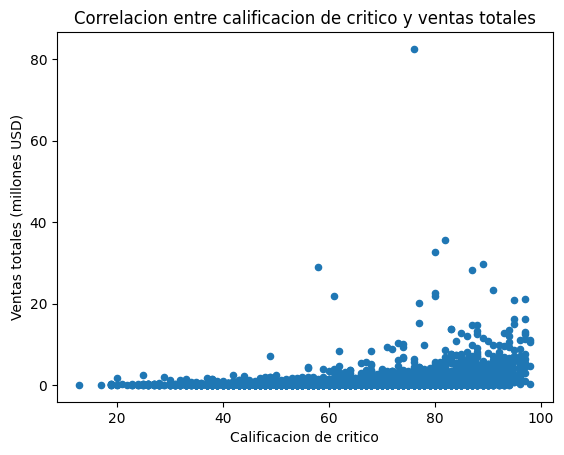

Coeficiente de correlacion de Pearson:
0.24550668717736357


In [ ]:
df_games_con_critic_score = df_games[~(df_games['critic_score'] == -1)]
df_games_con_critic_score.plot(x='critic_score', y='total_sales', kind='scatter')
plt.title('Correlacion entre calificacion de critico y ventas totales')
plt.xlabel('Calificacion de critico')
plt.ylabel('Ventas totales (millones USD)')
plt.show()

print('Coeficiente de correlacion de Pearson:')
print(df_games_con_critic_score['total_sales'].corr(df_games_con_critic_score['critic_score']))


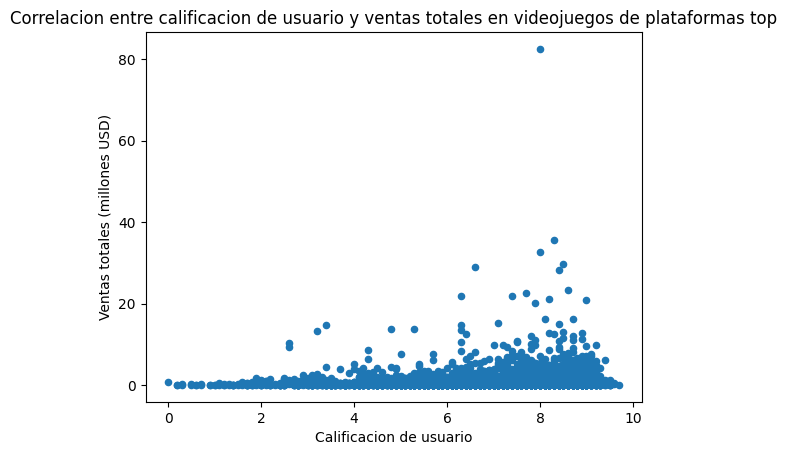

Coeficiente de correlacion de Pearson:
0.08885161696565043


In [ ]:
df_games_con_user_score[df_games_con_user_score['platform'].isin(top_platforms)].plot(x='user_score', y='total_sales', kind='scatter')
plt.title('Correlacion entre calificacion de usuario y ventas totales en videojuegos de plataformas top')
plt.xlabel('Calificacion de usuario')
plt.ylabel('Ventas totales (millones USD)')
plt.show()

print('Coeficiente de correlacion de Pearson:')
print(df_games_con_user_score[df_games_con_user_score['platform'].isin(top_platforms)]['total_sales'].corr(df_games_con_user_score[df_games_con_user_score['platform'].isin(top_platforms)]['user_score']))


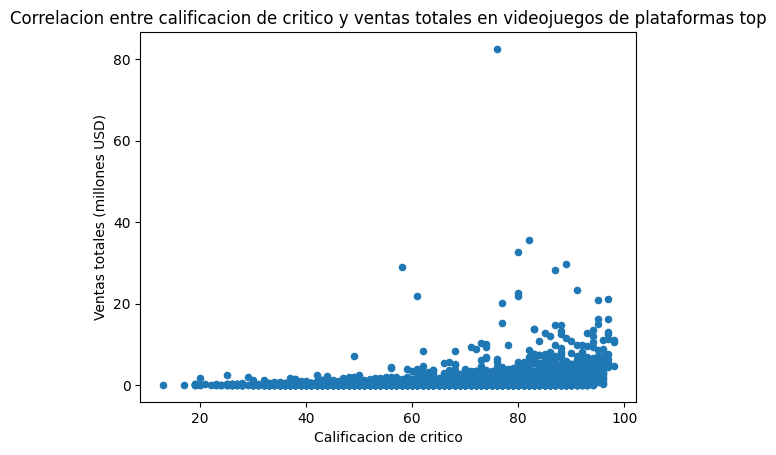

Coeficiente de correlacion de Pearson:
0.24893257773070973


In [38]:
df_games_con_critic_score[df_games_con_critic_score['platform'].isin(top_platforms)].plot(x='critic_score', y='total_sales', kind='scatter')
plt.title('Correlacion entre calificacion de critico y ventas totales en videojuegos de plataformas top')
plt.xlabel('Calificacion de critico')
plt.ylabel('Ventas totales (millones USD)')
plt.show()

print('Coeficiente de correlacion de Pearson:')
print(df_games_con_critic_score[df_games_con_critic_score['platform'].isin(top_platforms)]['total_sales'].corr(df_games_con_critic_score[df_games_con_critic_score['platform'].isin(top_platforms)]['critic_score']))



"No parece haber una correlación significativa entre las calificaciones de usuarios o críticos y el volumen de las ventas de un videojuego. Si acaso se observa una ligera correlación positiva entre ventas totales y calificación de crítico. Estas dos observaciones se encuentran tanto para todos los videojuegos como para los videojuegos de las plataformas top en ventas."

### Comparación de ventas entre plataformas de un mismo videojuego.

In [ ]:
duplicados_nombres = df_games[df_games.duplicated(subset=['name'], keep=False)]
duplicados_nombres = duplicados_nombres.sort_values('name')
duplicados_nombres = duplicados_nombres.reset_index(drop=True)
print('Mediana de ventas por plataforma en el subconjutno de juegos multiplataforma:')
print(duplicados_nombres.groupby('platform').median()['total_sales'].sort_values())
print()
print('Promedio de ventas por plataforma en el subconjutno de juegos multiplataforma:')
print(duplicados_nombres.groupby('platform').mean()['total_sales'].sort_values())


Mediana de ventas por plataforma en el subconjutno de juegos multiplataforma:
platform
PC      0.06
NG      0.07
PSV     0.09
3DS     0.13
DC      0.14
GC      0.14
WiiU    0.15
XB      0.15
DS      0.16
GBA     0.16
PSP     0.17
SAT     0.17
XOne    0.22
Wii     0.23
PS4     0.26
X360    0.31
PS3     0.32
N64     0.34
PS2     0.38
WS      0.38
PS      0.52
SNES    0.99
2600    1.35
GEN     1.38
GB      1.61
NES     1.67
Name: total_sales, dtype: float64

Promedio de ventas por plataforma en el subconjutno de juegos multiplataforma:
platform
NG      0.110000
PSV     0.150927
SAT     0.210811
GC      0.242904
PC      0.278317
WiiU    0.317400
DC      0.330000
XB      0.330606
PSP     0.341726
3DS     0.351448
DS      0.362839
WS      0.380000
GBA     0.384391
Wii     0.509243
XOne    0.603080
N64     0.689898
PS3     0.746591
PS2     0.766781
X360    0.783379
PS4     0.873769
PS      0.952512
GEN     1.558000
2600    1.830000
SNES    2.068824
GB      3.301579
NES     4.008519
Name: tota

In [ ]:
# Juegos que aparecen en al menos 3 plataformas
juegos_multiplataforma = duplicados_nombres['name'].value_counts()
juegos_populares = juegos_multiplataforma[juegos_multiplataforma >= 3].index
print('Ventas desglosadas por plataforma para los juegos liberados en más plataformas: ')
for juego in juegos_populares[:5]:  # Top 5 ejemplos
    ventas_juego = duplicados_nombres[duplicados_nombres['name'] == juego]
    print(f"\n{juego}:")
    print(ventas_juego[['year_of_release', 'platform', 'total_sales', 'genre']].sort_values('total_sales', ascending=False))


Ventas desglosadas por plataforma para los juegos liberados en más plataformas: 

Need for Speed: Most Wanted:
      year_of_release platform  total_sales   genre
4603             2005      PS2         4.37  Racing
4601             2012      PS3         2.81  Racing
4602             2012     X360         1.56  Racing
4604             2005     X360         1.25  Racing
4608             2005       XB         1.04  Racing
4609             2012      PSV         1.01  Racing
4611             2005       GC         0.56  Racing
4605             2005       PC         0.29  Racing
4607             2005       DS         0.27  Racing
4612             2013     WiiU         0.27  Racing
4606             2005      GBA         0.26  Racing
4610             2012       PC         0.08  Racing

Madden NFL 07:
      year_of_release platform  total_sales   genre
3535             2006      PS2         4.49  Sports
3534             2006     X360         1.80  Sports
3536             2006       XB         1.

"Construimos tres tablas para explorar el comportamiento de ventas en juegos multiplataforma. En la primera revisamos las medianas de los juegos agrupados por plataforma, y vimos que se mantiene el comportamiento observado en la sección antepenúltima con los gráficos de cajas y bigotes para ventas totales por plataforma. En la segunda vemos la media para considerar los valores atípicos dentro de nuestra representación de las distribuciones de ventas en cada plataforma. Igual aquí observamos que las plataformas con medias de ventas totales más altas son plataformas antiguas, debido a que liberan menos juegos y además el mercado era más nuevo. En la tercera observamos varias tablas que nos muestran ventas totales en el subconjunto de videojuegos liberados en la mayor cantidad de plataformas. Estas tablas muestran un comportamiento interesante en el sentido que podemos observar que, incluso juegos con ventas importantes en una plataforma, en otras plataformas las ventas son una fracción pequeña  de la plataforma donde vendió más, aun siendo estas las plataformas más populares en el tiempo de la liberación del juego (consideramos que un videojuego pensado para multiplataforma se libera en las plataformas más populares de su época). Por lo tanto, parece ser que las ventas dependen más del juego correcto para cada plataforma (incluso puede que dependa de la correlación de géneros que se dan para cada plataforma y para lo tanto con el perfil de usuario para cada plataforma)."

### Análisis por genero.
Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

In [ ]:
# Filtramos los juegos que no tienen sin_genero en la columna 'genre'
df_games_con_genre = df_games[~(df_games['genre'] == 'sin_genero')]


In [ ]:
# contar juegos por gnero y asi ver los pupulares. tambien ver calificaciones y ver popularidad. ver ventas
print('Generos por popularidad (Numero de juegos por genero):')
print(df_games_con_genre.groupby('genre').count()['name'].sort_values(ascending=False))


Generos por popularidad (Numero de juegos por genero):
genre
Action          3369
Sports          2348
Misc            1750
Role-Playing    1498
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       873
Fighting         849
Strategy         683
Puzzle           580
Name: name, dtype: int64


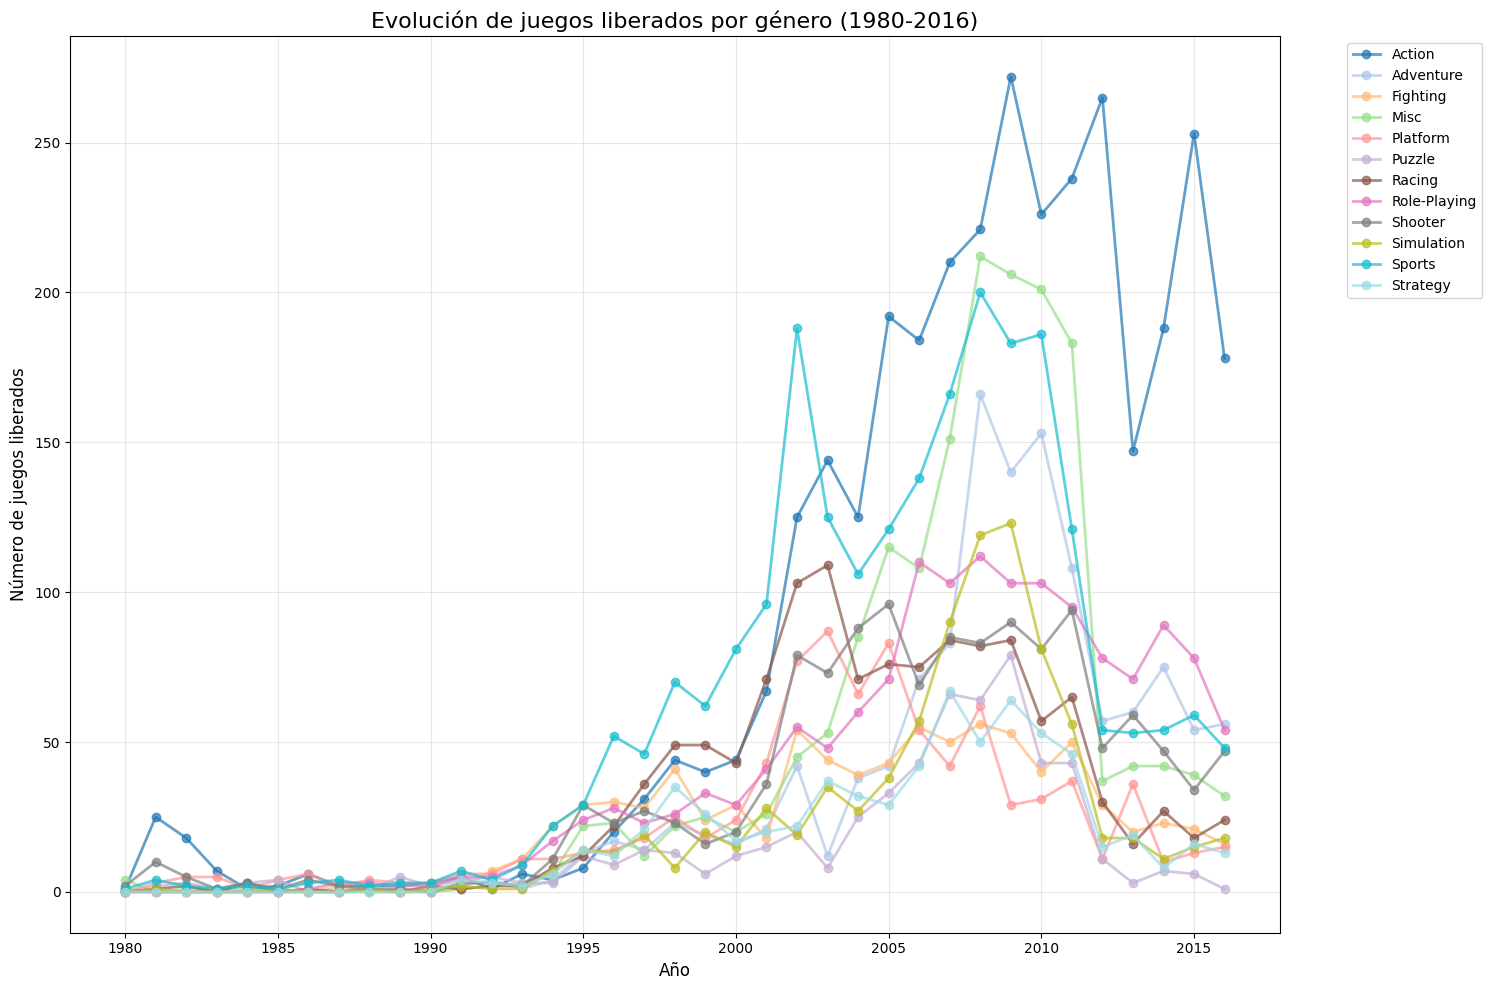

In [ ]:
tabla_generos = (
    df_games_con_genre[df_games_con_genre['year_of_release'] != 0]
    .groupby(['year_of_release', 'genre'])
    .size()
    .unstack(fill_value=0)
)

tabla_generos.plot(
    figsize=(15, 10),
    marker='o',
    linewidth=2,
    alpha=0.7,
    colormap='tab20' 
)

plt.title('Evolución de juegos liberados por género (1980-2016)', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de juegos liberados', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print('Generos por ventas (ventas de juegos en mdd por genero):')
print(df_games_con_genre.groupby('genre')['total_sales'].sum().sort_values(ascending=False))


Generos por ventas (ventas de juegos en mdd por genero):
genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Name: total_sales, dtype: float64


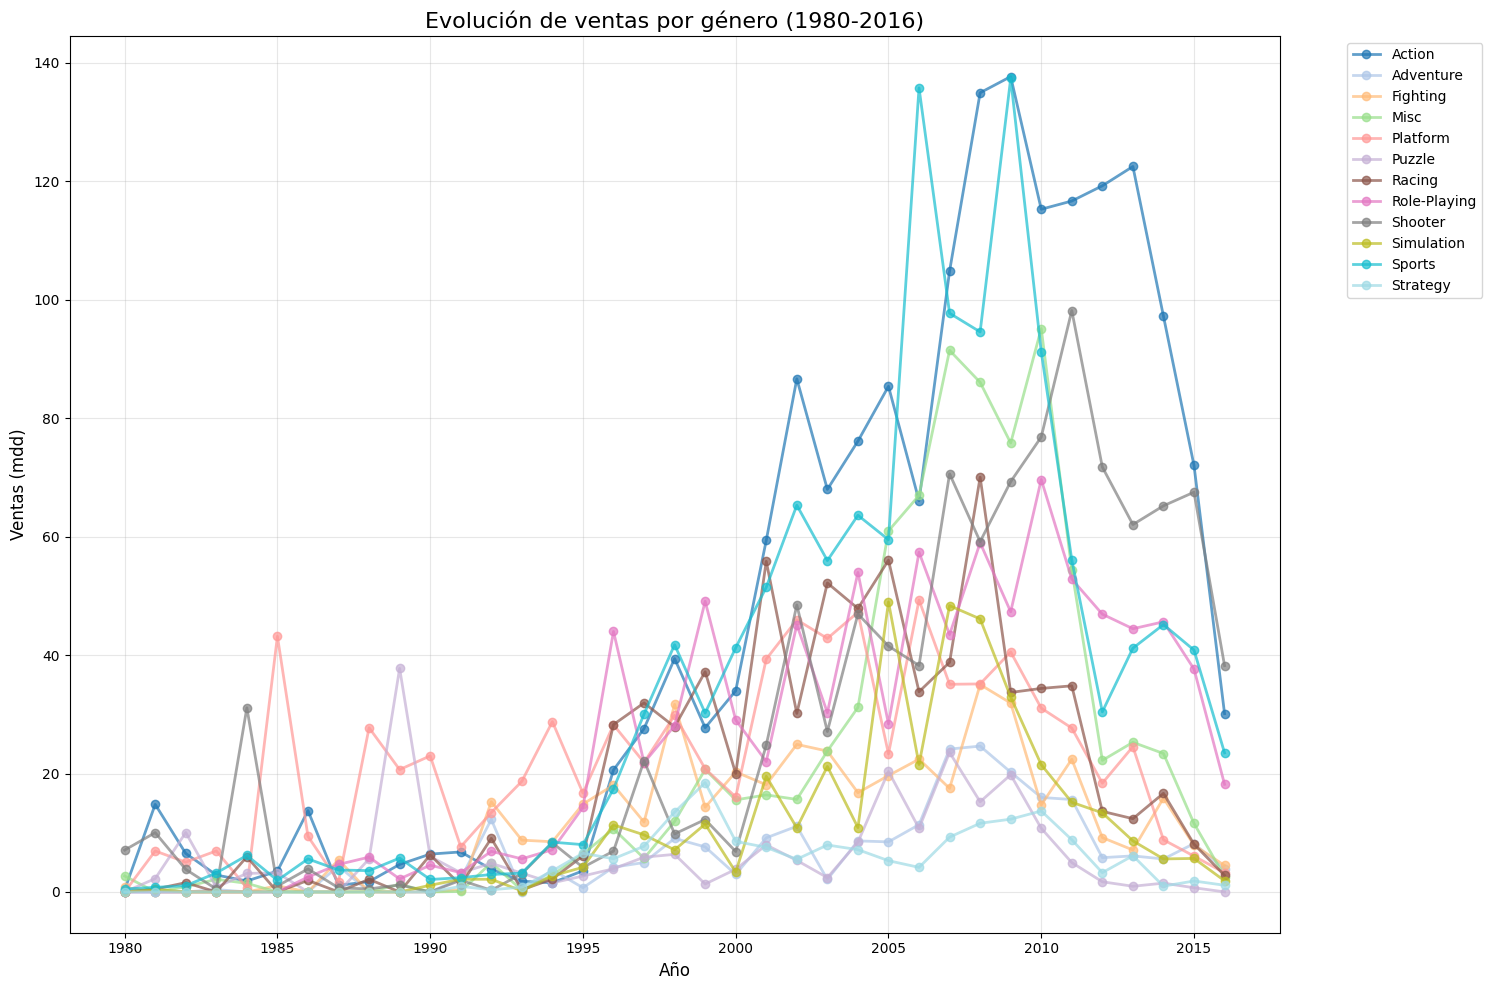

In [ ]:
tabla_generos = (
    df_games_con_genre[df_games_con_genre['year_of_release'] != 0]
    .groupby(['year_of_release', 'genre'])['total_sales']
    .sum()
    .unstack(fill_value=0)
)

tabla_generos.plot(
    figsize=(15, 10),
    marker='o',
    linewidth=2,
    alpha=0.7,
    colormap='tab20' 
)

plt.title('Evolución de ventas por género (1980-2016)', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ventas (mdd)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


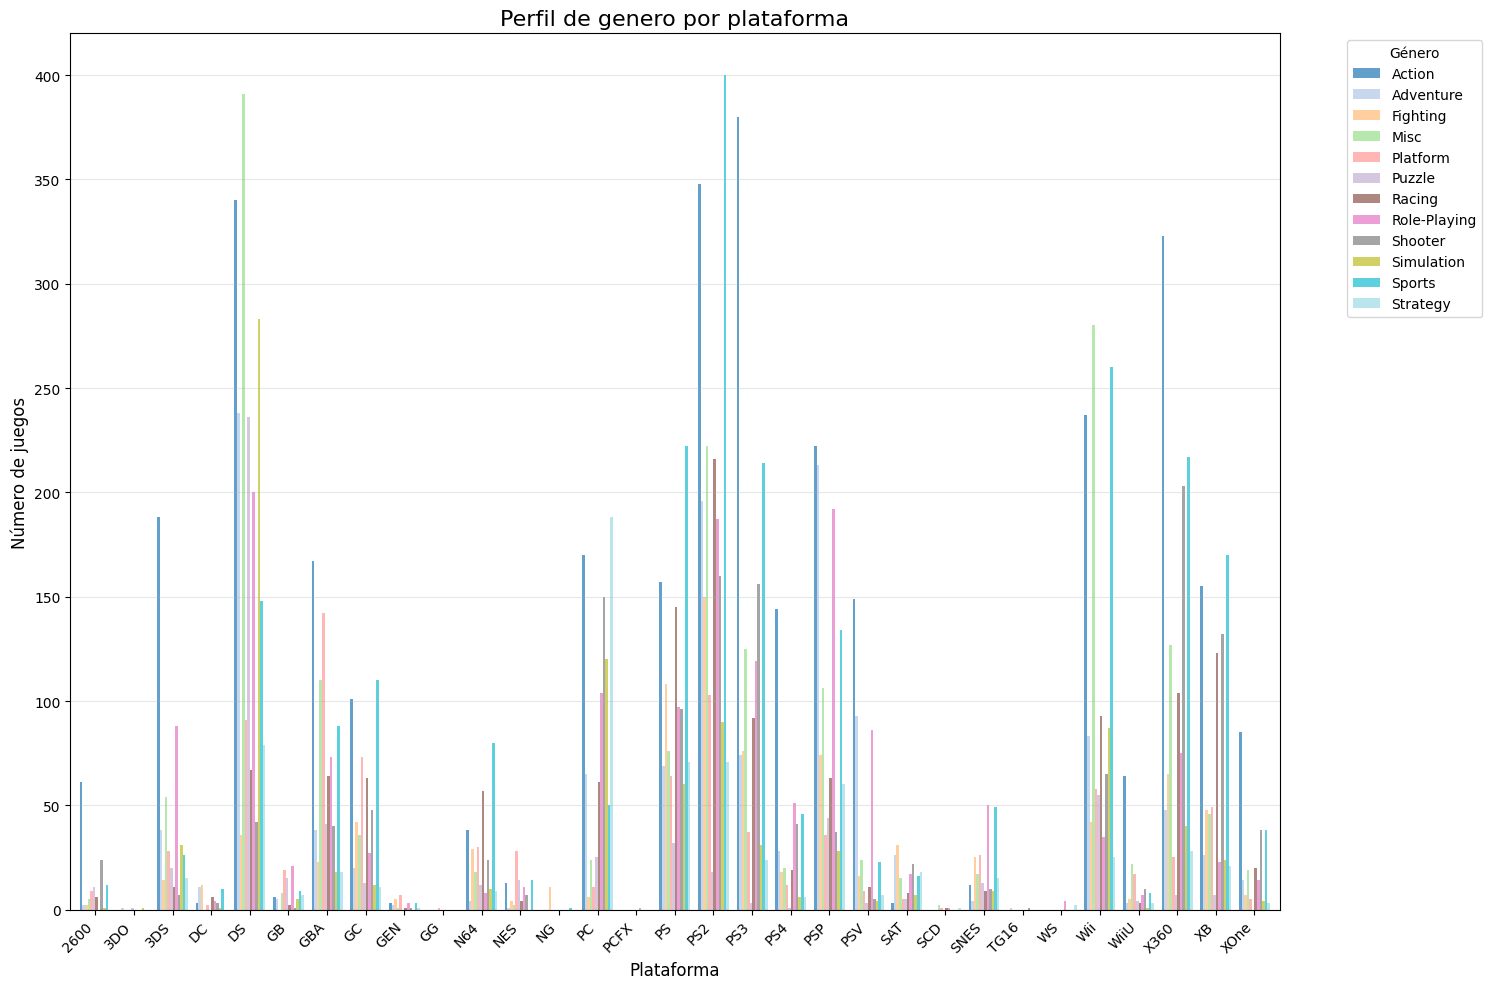

In [46]:

# genero y plataforma
tabla_generos = (
    df_games_con_genre
    .groupby(['platform', 'genre'])
    .size()
    .unstack(fill_value=0)
)

tabla_generos.plot(
    kind='bar',
    figsize=(15, 10),
    colormap='tab20',
    alpha=0.7,
    width=0.8
)

plt.title('Perfil de genero por plataforma', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Número de juegos', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Género')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


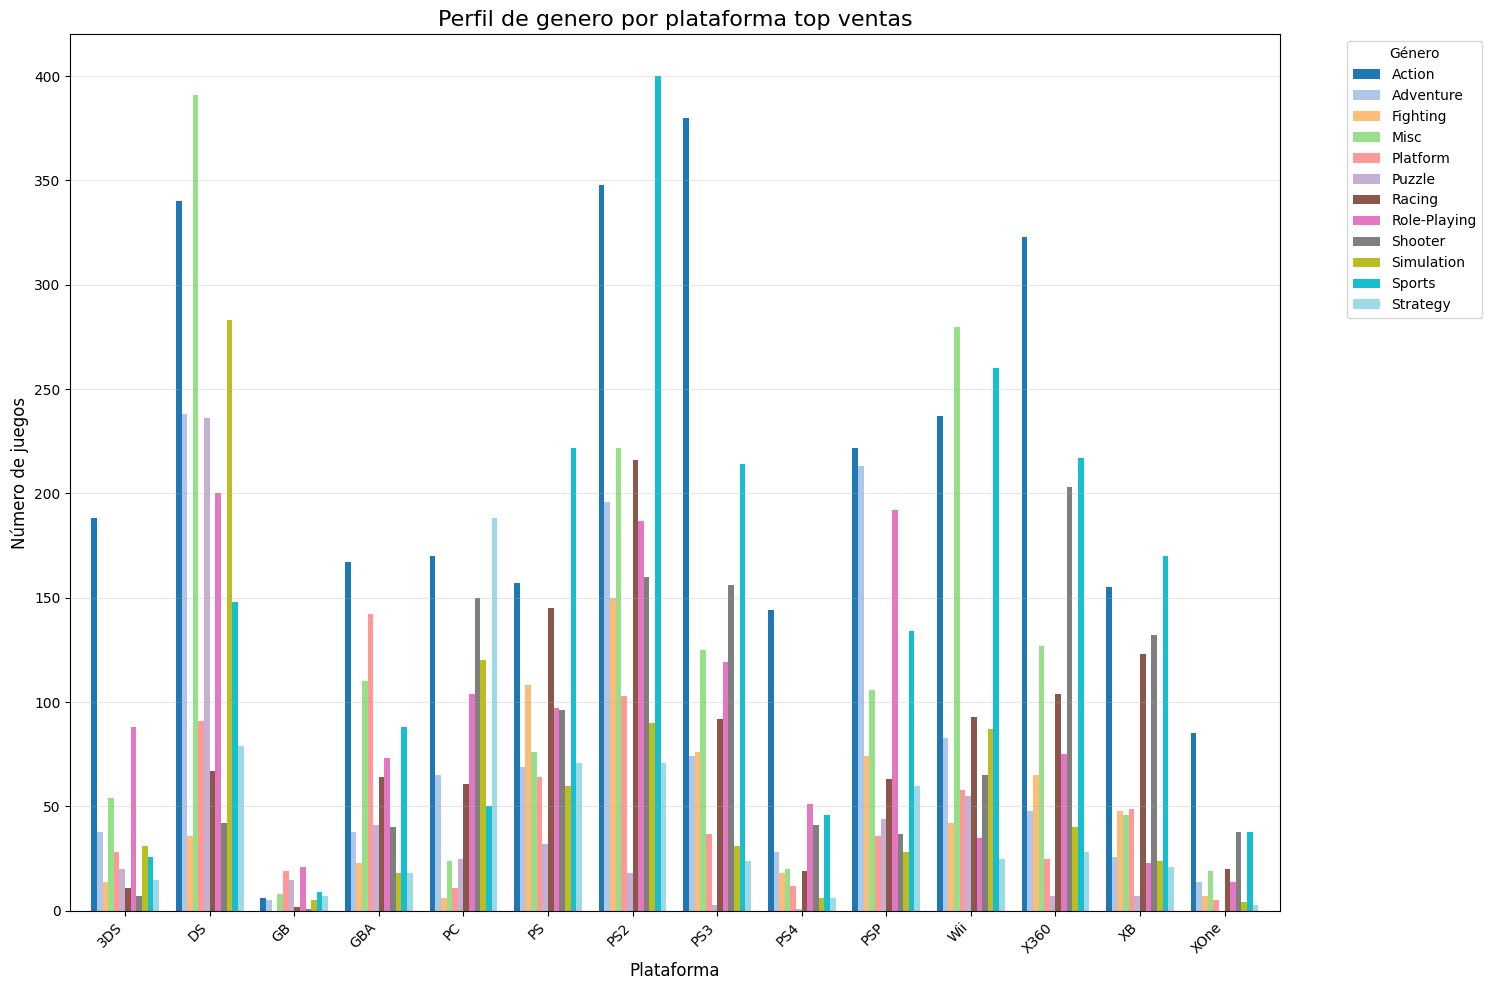

In [ ]:
# genero y plataforma
tabla_generos = (
    df_games_con_genre[df_games_con_genre['platform'].isin(top_platforms)]
    .groupby(['platform', 'genre'])
    .size()
    .unstack(fill_value=0)
)

tabla_generos.plot(
    kind='bar',
    figsize=(15, 10),
    colormap='tab20',
    alpha=1,
    width=0.8
)

plt.title('Perfil de genero por plataforma top ventas', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Número de juegos', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Género')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


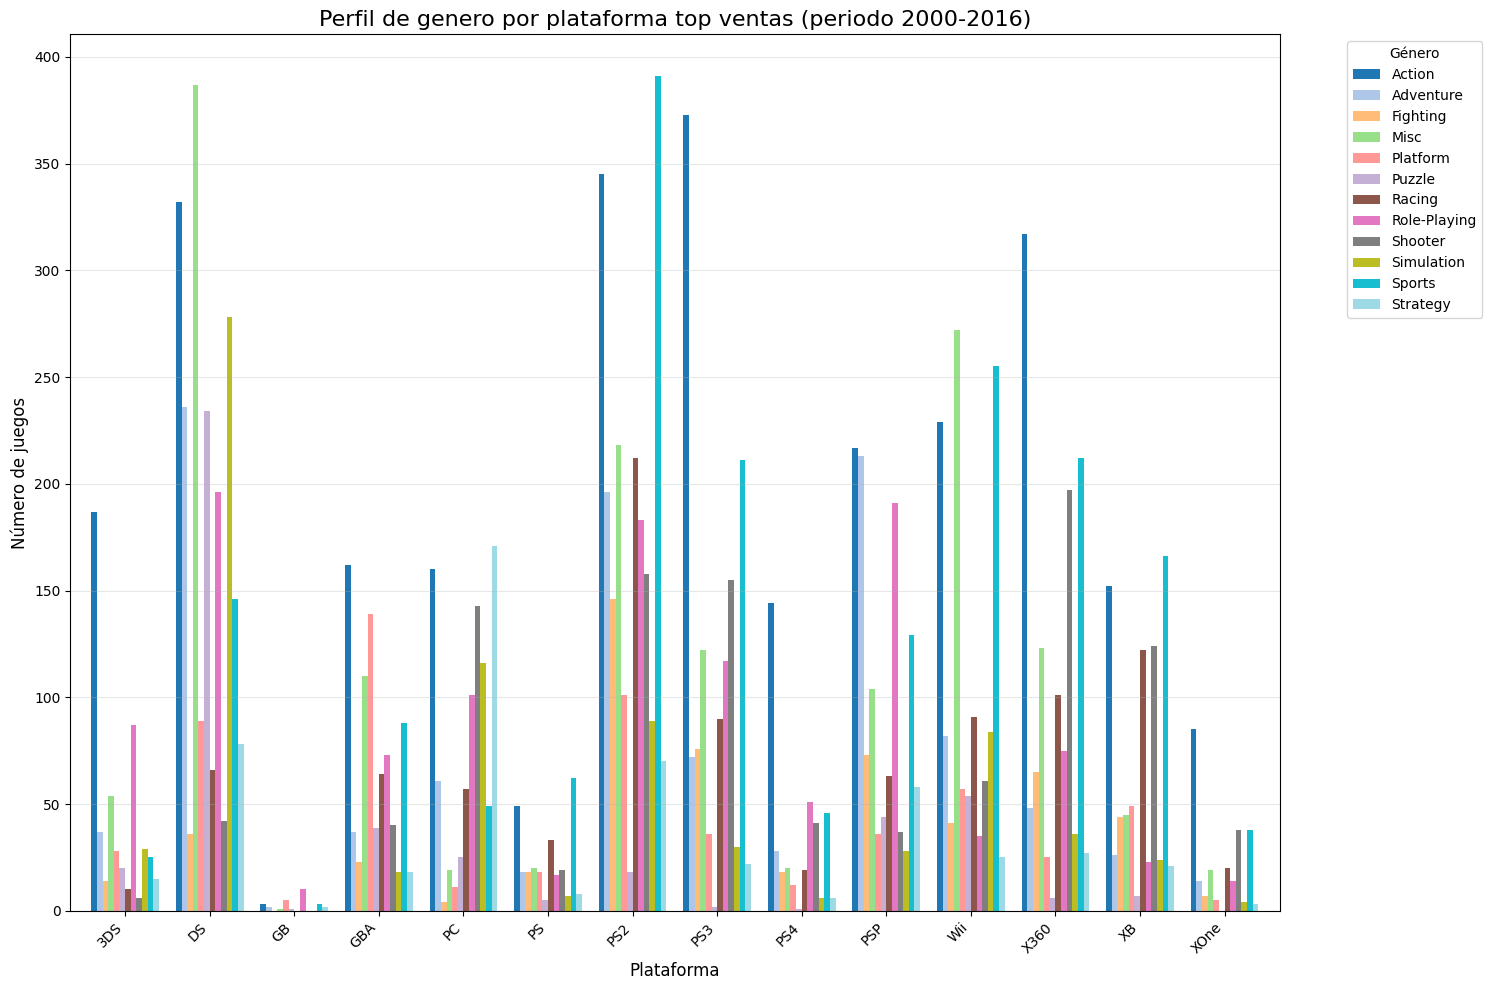

In [ ]:
#hoy en dia cual es el perfil de genero de cada plataforma. filtrar por year of release


# genero y plataforma
tabla_generos = (
    df_games_con_genre[(df_games_con_genre['platform'].isin(top_platforms)) & (df_games_con_genre['year_of_release'] >= 2000) & 
        (df_games_con_genre['year_of_release'] <= 2016)]
    .groupby(['platform', 'genre'])
    .size()
    .unstack(fill_value=0)
)

tabla_generos.plot(
    kind='bar',
    figsize=(15, 10),
    colormap='tab20',
    alpha=1,
    width=0.8
)

plt.title('Perfil de genero por plataforma top ventas (periodo 2000-2016)', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Número de juegos', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Género')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


"Ahora podemos ver que cada plataforma tiene su perfil de usuarios que juegan a determinados géneros en sus consolas. Entonces podemos ver que liberar un juego de puzzle en la consola 360 es una mala idea, pero liberarla en el DS o Wii no es tan mala idea. Además, si hacemos suponemos que las ventas acumuladas de los videojuegos realmente son ventas puntuales durante el año de su liberación, suposición no tan alocada en cuanto así suele ser el mercado de los videojuegos, entonces podemos observar la evolución de las ventas de los distintos géneros y cuáles eran y cuáles son hoy los géneros más rentables."

## Perfil de usuario para cada region. 

### Top 5 plataformas por región. 

In [ ]:
# Agrupamos por plataforma y vemos ventas en las 3 regiones. 

print('Top 5 plataformas en la region de NA (ventas en mdd):')
print(df_games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5))
print()
print('Top 5 plataformas en la region de EU (ventas en mdd):')
print(df_games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5))
print()
print('Top 5 plataformas en la region de JP (ventas en mdd):')
print(df_games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5))


Top 5 plataformas en la region de NA (ventas en mdd):
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 plataformas en la region de EU (ventas en mdd):
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 plataformas en la region de JP (ventas en mdd):
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


### Top 5 géneros por región.

In [ ]:
# Agrupamos por genero y vemos ventas en las 3 regiones. 

print('Top 5 generos en la region de NA (ventas en mdd):')
print(df_games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5))
print()
print('Top 5 generos en la region de EU (ventas en mdd):')
print(df_games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5))
print()
print('Top 5 generos en la region de JP (ventas en mdd):')
print(df_games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5))


Top 5 generos en la region de NA (ventas en mdd):
genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Top 5 generos en la region de EU (ventas en mdd):
genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Top 5 generos en la region de JP (ventas en mdd):
genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


### Efectos de clasificación ESRB en ventas de la región. 

In [ ]:
df_con_rating = df_games[df_games['rating'] != 'sin_rating']
print('Juegos por categoria de clasificacion ESRB:')
print(df_con_rating['rating'].value_counts())
print()
print('Ventas por clasificacion ESRB en la region de NA (ventas en mdd):')
print(df_con_rating.groupby('rating')['na_sales'].sum().sort_values(ascending=False).head(5))
print()
print('Ventas por clasificacion ESRB en la region de EU (ventas en mdd):')
print(df_con_rating.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).head(5))
print()
print('Ventas por clasificacion ESRB en la region de JP (ventas en mdd):')
print(df_con_rating.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).head(5))


Juegos por categoria de clasificacion ESRB:
E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: rating, dtype: int64

Ventas por clasificacion ESRB en la region de NA (ventas en mdd):
rating
E       1292.99
T        759.75
M        748.48
E10+     353.32
K-A        2.56
Name: na_sales, dtype: float64

Ventas por clasificacion ESRB en la region de EU (ventas en mdd):
rating
E       710.25
M       483.97
T       427.03
E10+    188.52
AO        0.61
Name: eu_sales, dtype: float64

Ventas por clasificacion ESRB en la region de JP (ventas en mdd):
rating
E       198.11
T       151.40
M        64.24
E10+     40.20
K-A       1.46
Name: jp_sales, dtype: float64


"A partir de las agrupaciones y tablas generadas, observamos que la región con más ventas es la región de NA. También, podemos observar que en cuanto a perfil de plataformas y géneros por región, NA y EU tienen un perfil muy similar, siendo la región de JP la que presenta un perfil más diferenciado al de las otras 2 regiones. También podemos observar que en las 3 regiones los juegos con calificación E son los que más se venden. Es importante notar que los juegos de calificación E, también son los más abundantes, seguido por los juegos de calificación T y en tercer lugar los juegos de calificación M. Esto es interesante, ya que tanto en la región de NA como EU vemos que los juegos de calificación M tienen ventas acumuladas muy próximas a las de los juegos de calificación T, aun habiendo casi el doble de juegos liberados de calificación T."

## Pruebas de hipótesis.

Probaremos las siguientes hipótesis:

— Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

— Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

### Calificaciones promedio de los usuarios para las plataformas XOne y PC.

Vamos a hacer una prueba de hipótesis donde nuestra hipótesis nula es que no existe una diferencia estadísticamente significativa entre las calificaciones promedio de los usuarios para las plataformas XOne y PC. La hipótesis alternativa es que sí existe una diferencia estadísticamente significativa. Formalmente, estaría expresado de la siguiente manera:

H0 = No existe una diferencia real de las calificaciones promedio de los usuarios entre las dos plataformas; la diferencia observada entre las medias muestrales se debe únicamente al error de muestreo (azar).

H1 = Existe una diferencia significativa de las calificaciones promedio de los usuarios entre las dos plataformas; es altamente improbable que la diferencia observada haya ocurrido por puro azar bajo el supuesto de una distribución común.

In [55]:
# Prueba las hipótesis


calificacion_usuario_xone = df_games_con_user_score[df_games_con_user_score['platform'] == 'XOne']['user_score']
calificacion_usuario_pc = df_games_con_user_score[df_games_con_user_score['platform'] == 'PC']['user_score']

alpha = 0.05

results = st.ttest_ind(calificacion_usuario_xone, calificacion_usuario_pc, equal_var=False)

print('Valor p:', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos H0')
else:
    print('No podemos rechazar H0')


Valor p: 4.935072360183574e-06
Rechazamos H0


### Calificaciones promedio de los usuarios para los géneros de Acción y Deportes.

Vamos a hacer una prueba de hipótesis donde nuestra hipótesis nula es que no existe una diferencia estadísticamente significativa entre las calificaciones promedio de los usuarios para los géneros de Acción y Deporte. La hipótesis alternativa es que sí existe una diferencia estadísticamente significativa. Formalmente, estaría expresado de la siguiente manera:

H0 = No existe una diferencia real de las calificaciones promedio de los usuarios entre los géneros de Acción y Deporte; la diferencia observada entre las medias muestrales se debe únicamente al error de muestreo (azar).

H1 = Existe una diferencia significativa de las calificaciones promedio de los usuarios entre los géneros de Acción y Deporte; es altamente improbable que la diferencia observada haya ocurrido por puro azar bajo el supuesto de una distribución común.

In [ ]:
calificacion_usuario_accion = df_games_con_user_score[df_games_con_user_score['genre'] == 'Action']['user_score']
calificacion_usuario_sports = df_games_con_user_score[df_games_con_user_score['genre'] == 'Sports']['user_score']

alpha = 0.05

results = st.ttest_ind(calificacion_usuario_accion, calificacion_usuario_sports, equal_var=False)

print('Valor p:', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos H0')
else:
    print('No podemos rechazar H0')


Valor p: 0.11483818791498286
No podemos rechazar H0


"A partir de las pruebas de hipótesis que realizamos, identificamos que hay una diferencia estadística significativa entre las calificaciones de usuario de las plataformas XOne y PC. Por otro lado, cuando vemos las calificaciones de usuario en función del género Acción y Deportes, vemos que, por lo menos con esta prueba, parece ser que las diferencias observadas entre las calificaciones de usuario se debe al azar y no tanto a la existencia de dos poblaciones estadísticas distintas."

## Conclusión. 

"A lo largo del proyecto hemos podido identificar ciertos patrones de venta importantes en el mercado de videojuegos. Unos de los que, a mi parecer, resultan más importantes es haber identificado que cada plataforma tiene su perfil de usuario con sus géneros preferidos, y que el éxito en ventas que pueda tener un videojuego está relacionado con el género al que pertenece y si el género es popular entre los usuarios en el conjunto de plataformas que se planea liberar. También es importante notar que las plataformas suelen tener un ciclo de vida que es importante tomar en cuenta al momento de la planeación de liberaciones de videojuego. Por último quisiera también remarcar que, actualmente la liberación de videojuegos parece haber disminuido su actividad comprándolo con el momento máximo que se dio entre principios de los 2000 y 2013. Es importante notar que es un mercado que parece estar disminuyendo su capacidad de retorno de inversión o que parece estar estabilizándose. "
